In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd "/content/drive/MyDrive/Dataset/models"
!ls

/content/drive/MyDrive/Dataset/models
 Baseline  'Paper based ANN'  'Paper based DNN'


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [4]:
model = load_model("/content/drive/MyDrive/Dataset/models/Paper based DNN/model.h5")

train_df = pd.read_csv("/content/drive/MyDrive/Dataset/UNSW_NB15_training-set.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Dataset/UNSW_NB15_testing-set.csv")

In [5]:
def prepare_prediction_data(train_df, test_df):
  excluded_cols = ["id", "label", "attack_cat"]

  train_features = train_df.drop(columns=excluded_cols)
  test_features = test_df.drop(columns=excluded_cols)

  train_labels_text = train_df["attack_cat"]
  test_labels_text = test_df["attack_cat"]

  label_encoder = LabelEncoder()
  train_labels = label_encoder.fit_transform(train_labels_text)
  test_labels = label_encoder.transform(test_labels_text)

  categorical_cols = train_features.select_dtypes(include=["object"]).columns.tolist()

  train_features_encoded = pd.get_dummies(train_features, columns=categorical_cols)
  test_features_encoded = pd.get_dummies(test_features, columns=categorical_cols)

  train_features_encoded, test_features_encoded = train_features_encoded.align(
      test_features_encoded,
      join="left",
      axis=1,
      fill_value=0
  )

  train_features_encoded = train_features_encoded.astype(float)
  test_features_encoded = test_features_encoded.astype(float)

  scaler = StandardScaler()
  scaler.fit(train_features_encoded)

  test_features_scaled = scaler.transform(test_features_encoded)

  return test_features_scaled, test_labels, label_encoder

In [6]:
test_features_scaled, test_labels, label_encoder = prepare_prediction_data(
    train_df,
    test_df
)

In [14]:
test_labels.shape

(175341,)

In [7]:
def get_prediction(
    model,
    test_df,
    test_features_scaled,
    test_labels,
    label_encoder,
    sample_index
):
  sample_features = test_features_scaled[sample_index].reshape(1, -1)

  probabilities = model.predict(sample_features, verbose=0)[0]

  predicted_index = np.argmax(probabilities)

  predicted_label = label_encoder.inverse_transform([predicted_index])[0]
  true_label = label_encoder.inverse_transform([test_labels[sample_index]])[0]

  probability_df = pd.DataFrame({
      "Class": label_encoder.classes_,
      "Probability": probabilities
  }).sort_values(by="Probability", ascending=False)

  print("Sample index:", sample_index)
  print("True label:", true_label)
  print("Predicted label:", predicted_label)
  print("Confidence:", probabilities[predicted_index])
  print("Correct prediction:", true_label == predicted_label)

  print("\nOriginal network traffic sample:")
  display(test_df.iloc[[sample_index]])

  plt.figure(figsize=(10, 5))
  plt.bar(probability_df["Class"], probability_df["Probability"])
  plt.xticks(rotation=45)
  plt.title(f"Prediction probabilities for sample {sample_index}")
  plt.xlabel("Class")
  plt.ylabel("Probability")
  plt.show()

Sample index: 93947
True label: DoS
Predicted label: DoS
Confidence: 0.5112136
Correct prediction: True

Original network traffic sample:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
93947,93948,0.000003,unas,-,INT,2,0,200,0,333333.3215,...,4,14,0,0,0,6,11,0,DoS,1


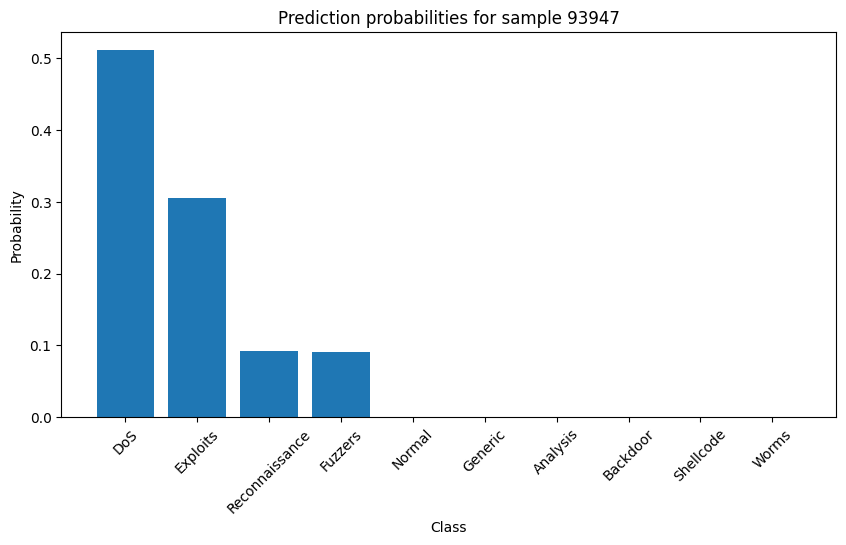

In [8]:
random_index = random.randint(0, len(test_df) - 1)

get_prediction(
    model,
    test_df,
    test_features_scaled,
    test_labels,
    label_encoder,
    sample_index=random_index
)

In [ ]:
import pandas as pd
import numpy as np

from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler, LabelEncoder

MODEL_PATH = "/content/drive/MyDrive/Dataset/models/Paper based DNN/model.h5"
TRAIN_PATH = "/content/drive/MyDrive/Dataset/UNSW_NB15_training-set.csv"
TEST_PATH = "/content/drive/MyDrive/Dataset/UNSW_NB15_testing-set.csv"

EXCLUDED_COLS = ["id", "label", "attack_cat"]
def load_model_and_train_data():
    print("Loading model and training dataset...")

    model = load_model(MODEL_PATH)
    train_df = pd.read_csv(TRAIN_PATH)

    print("Model and dataset loaded successfully.")

    return model, train_df


def prepare_preprocessing_objects(train_df):
    train_features = train_df.drop(columns=EXCLUDED_COLS)
    train_labels_text = train_df["attack_cat"]

    label_encoder = LabelEncoder()
    label_encoder.fit(train_labels_text)

    categorical_cols = train_features.select_dtypes(include=["object"]).columns.tolist()
    numeric_cols = train_features.select_dtypes(include=np.number).columns.tolist()

    train_encoded = pd.get_dummies(
        train_features,
        columns=categorical_cols
    )

    train_encoded = train_encoded.astype(float)

    scaler = StandardScaler()
    scaler.fit(train_encoded)

    train_columns = train_encoded.columns.tolist()

    return label_encoder, scaler, train_columns, categorical_cols, numeric_cols, train_features


def ask_categorical_input(column_name, train_df):
    unique_values = sorted(train_df[column_name].dropna().unique().tolist())

    print(f"\nColumn: {column_name}")
    print("Type: categorical")
    print("Possible values:")

    for i, value in enumerate(unique_values):
        print(f"{i} -> {value}")

    while True:
        user_input = input("Choose value by index or type value manually: ").strip()

        if user_input.isdigit():
            index = int(user_input)

            if 0 <= index < len(unique_values):
                return unique_values[index]
            else:
                print("Invalid index. Try again.")

        elif user_input != "":
            return user_input

        else:
            print("Value cannot be empty.")


def ask_numeric_input(column_name, train_features):
    column_median = train_features[column_name].median()

    print(f"\nColumn: {column_name}")
    print("Type: numeric")
    print(f"Suggested value / median: {column_median}")

    while True:
        user_input = input("Enter numeric value: ").strip()

        if user_input == "":
            print("Value cannot be empty.")
            continue

        try:
            return float(user_input)
        except ValueError:
            print("Invalid number. Try again.")


def create_manual_sample(train_df, train_features, categorical_cols, numeric_cols):
    sample_data = {}

    print("\n" + "=" * 60)
    print("Manual Network Traffic Input")
    print("=" * 60)

    print(
        "\nYou will now enter the values for each feature used by the model."
    )

    for column in train_features.columns:
        if column in categorical_cols:
            value = ask_categorical_input(column, train_df)
        elif column in numeric_cols:
            value = ask_numeric_input(column, train_features)
        else:
            print(f"\nColumn {column} has unknown type. Asking as text.")
            value = input(f"Enter value for {column}: ").strip()

        sample_data[column] = value

    sample_df = pd.DataFrame([sample_data])

    return sample_df


def preprocess_manual_sample(sample_df, train_columns, scaler, categorical_cols):
    sample_encoded = pd.get_dummies(
        sample_df,
        columns=categorical_cols
    )

    sample_encoded = sample_encoded.reindex(
        columns=train_columns,
        fill_value=0
    )

    sample_encoded = sample_encoded.astype(float)

    sample_scaled = scaler.transform(sample_encoded)

    return sample_scaled


def predict_manual_sample(model, sample_scaled, label_encoder):
    probabilities = model.predict(sample_scaled, verbose=0)[0]

    predicted_index = np.argmax(probabilities)
    predicted_label = label_encoder.inverse_transform([predicted_index])[0]
    confidence = probabilities[predicted_index]

    probability_df = pd.DataFrame({
        "Class": label_encoder.classes_,
        "Probability": probabilities
    }).sort_values(by="Probability", ascending=False)

    return predicted_label, confidence, probability_df


def show_prediction_result(sample_df, predicted_label, confidence, probability_df):
    print("\n" + "=" * 60)
    print("Manual Sample Created")
    print("=" * 60)
    print(sample_df.to_string(index=False))

    print("\n" + "=" * 60)
    print("Prediction Result")
    print("=" * 60)

    print(f"Predicted class: {predicted_label}")
    print(f"Confidence: {confidence:.4f}")

    print("\nClass probabilities:")
    print(probability_df.to_string(index=False))


def run_manual_prediction():
    model, train_df = load_model_and_train_data()

    (
        label_encoder,
        scaler,
        train_columns,
        categorical_cols,
        numeric_cols,
        train_features
    ) = prepare_preprocessing_objects(train_df)

    print("\nModel classes:")
    for index, class_name in enumerate(label_encoder.classes_):
        print(f"{index} -> {class_name}")

    while True:
        sample_df = create_manual_sample(
            train_df,
            train_features,
            categorical_cols,
            numeric_cols
        )

        sample_scaled = preprocess_manual_sample(
            sample_df,
            train_columns,
            scaler,
            categorical_cols
        )

        expected_input_dim = model.input_shape[1]
        actual_input_dim = sample_scaled.shape[1]

        if expected_input_dim != actual_input_dim:
            print("\nERROR: Input shape mismatch.")
            print(f"Model expects: {expected_input_dim} features")
            print(f"Current sample has: {actual_input_dim} features")
            print("Check that preprocessing matches the training notebook.")
            break

        predicted_label, confidence, probability_df = predict_manual_sample(
            model,
            sample_scaled,
            label_encoder
        )

        show_prediction_result(
            sample_df,
            predicted_label,
            confidence,
            probability_df
        )

        again = input("\nDo you want to test another sample? [y/n]: ").strip().lower()

        if again != "y":
            print("Exiting prediction demo.")
            break


if __name__ == "__main__":
    run_manual_prediction()

Loading model and training dataset...
Model and dataset loaded successfully.

Model classes:
0 -> Analysis
1 -> Backdoor
2 -> DoS
3 -> Exploits
4 -> Fuzzers
5 -> Generic
6 -> Normal
7 -> Reconnaissance
8 -> Shellcode
9 -> Worms

Manual Network Traffic Input

You will now enter the values for each feature used by the model.

Column: dur
Type: numeric
Suggested value / median: 0.014138

Column: proto
Type: categorical
Possible values:
0 -> 3pc
1 -> a/n
2 -> aes-sp3-d
3 -> any
4 -> argus
5 -> aris
6 -> arp
7 -> ax.25
8 -> bbn-rcc
9 -> bna
10 -> br-sat-mon
11 -> cbt
12 -> cftp
13 -> chaos
14 -> compaq-peer
15 -> cphb
16 -> cpnx
17 -> crtp
18 -> crudp
19 -> dcn
20 -> ddp
21 -> ddx
22 -> dgp
23 -> egp
24 -> eigrp
25 -> emcon
26 -> encap
27 -> etherip
28 -> fc
29 -> fire
30 -> ggp
31 -> gmtp
32 -> gre
33 -> hmp
34 -> i-nlsp
35 -> iatp
36 -> ib
37 -> idpr
38 -> idpr-cmtp
39 -> idrp
40 -> ifmp
41 -> igmp
42 -> igp
43 -> il
44 -> ip
45 -> ipcomp
46 -> ipcv
47 -> ipip
48 -> iplt
49 -> ipnip
50 ->